In [1]:
import pathlib
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-darkgrid")
except OSError:
    plt.style.use("default")

repo_root = pathlib.Path.cwd()
while not (repo_root / "src").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if (repo_root / "src").exists() and str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.forces as forces_module
import src.integrator as integrator_module
import src.energy as energy_module
import src.simulate as simulate_module
import src.diagnostics as diagnostics_module
import src.visualize as visualize_module

importlib.reload(forces_module)
importlib.reload(integrator_module)
importlib.reload(energy_module)
importlib.reload(simulate_module)
importlib.reload(diagnostics_module)
importlib.reload(visualize_module)

from src.simulate import run_simulation
from src.energy import compute_total_energy
from src.integrator import compute_accelerations
from src.diagnostics import (
    mean_interparticle_separation,
    two_point_correlation,
    virial_ratio,
    energy_drift,
)
from src.visualize import (
    plot_trajectories,
    plot_snapshots,
    plot_pair_separation_histogram,
    plot_clustering_overlay,
)


In [2]:
def make_three_body_configuration():
    masses = np.array([1.0, 0.7, 0.5])
    positions = np.array([
        [-0.5, 0.0, 0.0],
        [0.5, 0.5, 0.1],
        [0.4, -0.3, -0.2],
    ], dtype=float)
    velocities = np.array([
        [0.0, 0.2, 0.0],
        [-0.3, 0.0, 0.0],
        [0.0, -0.1, 0.05],
    ], dtype=float)
    return positions, velocities, masses

def simulate_and_record(force_type, lam=None, mond_params=None, *, dt=0.001, steps=6000, softening=0.05):
    positions, velocities, masses = make_three_body_configuration()
    pos_hist, vel_hist = run_simulation(
        positions,
        velocities,
        masses,
        dt,
        steps,
        force_type=force_type,
        lam=lam,
        softening=softening,
        mond_params=mond_params,
    )
    energies = np.array([
        compute_total_energy(
            pos_hist[t],
            vel_hist[t],
            masses,
            force_type=force_type,
            lam=lam,
            softening=softening,
            mond_params=mond_params,
        )
        for t in range(steps)
    ])
    return {
        "force_type": force_type,
        "lambda": lam,
        "positions": pos_hist,
        "velocities": vel_hist,
        "energies": energies,
        "time": np.arange(steps) * dt,
        "dt": dt,
        "steps": steps,
        "softening": softening,
        "masses": masses,
        "mond_params": mond_params,
    }


In [3]:
mond_params = {"a0": 1e-2, "mu": "simple"}
newtonian_record = simulate_and_record("newtonian", dt=0.001, steps=6000, softening=0.05)
yukawa_record = simulate_and_record("yukawa", lam=1.0, dt=0.001, steps=6000, softening=0.05)
mond_record = simulate_and_record("mond", mond_params=mond_params, dt=0.001, steps=6000, softening=0.05)
records = [newtonian_record, yukawa_record, mond_record]

for rec in records:
    initial = rec["energies"][0]
    final = rec["energies"][-1]
    delta = final - initial
    rel_change = delta / abs(initial)
    max_dev = np.max(np.abs(rec["energies"] - initial))
    print(f"{rec['force_type']} (lam={rec['lambda']}, dt={rec['dt']}, steps={rec['steps']}, softening={rec['softening']}): final-init {delta:.3e}, rel {rel_change:+.2e}, max drift {max_dev:.3e}")


100%|██████████| 5999/5999 [00:00<00:00, 12607.98it/s]

100%|██████████| 5999/5999 [00:00<00:00, 9234.65it/s]



newtonian (lam=None, dt=0.001, steps=6000, softening=0.05): final-init 7.766e-08, rel +5.21e-08, max drift 2.512e-02
yukawa (lam=1.0, dt=0.001, steps=6000, softening=0.05): final-init 3.993e-05, rel +7.76e-05, max drift 1.923e-02
mond (lam=None, dt=0.001, steps=6000, softening=0.05): final-init -8.818e-04, rel -5.81e-04, max drift 2.340e-02


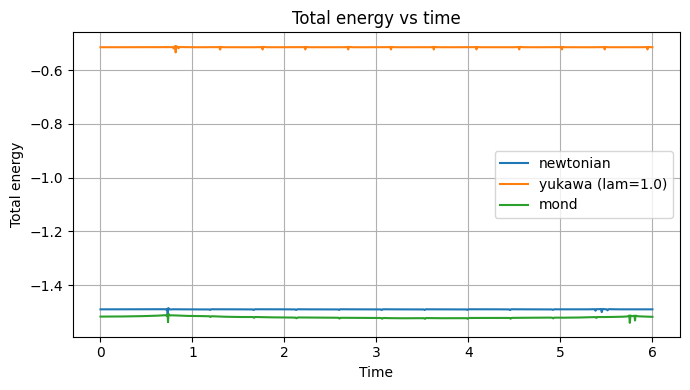

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for rec in records:
    label = f"{rec['force_type']}"
    if rec['lambda'] is not None:
        label += f" (lam={rec['lambda']})"
    ax.plot(rec['time'], rec['energies'], label=label)
ax.set_xlabel("Time")
ax.set_ylabel("Total energy")
ax.set_title("Total energy vs time")
ax.legend(loc="best")
ax.grid(True)
fig.tight_layout()

In [5]:
base_positions, _, base_masses = make_three_body_configuration()
acc_new = compute_accelerations(base_positions, base_masses, "newtonian")
acc_yuk = compute_accelerations(base_positions, base_masses, "yukawa", lam=1.0)
norms_new = np.linalg.norm(acc_new, axis=1)
norms_yuk = np.linalg.norm(acc_yuk, axis=1)
diffs = np.linalg.norm(acc_new - acc_yuk, axis=1)
print("Acceleration norm differences (Newtonian vs Yukawa lam=1.0):")
for idx, (n, y, d) in enumerate(zip(norms_new, norms_yuk, diffs)):
    print(f"  body {idx}: newtonian {n:.3f}, yukawa {y:.3f}, diff {d:.3f}")

Acceleration norm differences (Newtonian vs Yukawa lam=1.0):
  body 0: newtonian 0.994, yukawa 0.714, diff 0.280
  body 1: newtonian 1.294, yukawa 0.950, diff 0.346
  body 2: newtonian 1.592, yukawa 1.218, diff 0.375


In [6]:
bin_edges = np.linspace(0.1, 4.0, 9)
for rec in records:
    sep = mean_interparticle_separation(rec["positions"][-1])
    centers, xi = two_point_correlation(rec["positions"][-1], bin_edges)
    ratio = virial_ratio(
        rec["positions"][-1],
        rec["velocities"][-1],
        rec["masses"],
        rec["force_type"],
        rec["lambda"],
        rec["softening"],
        mond_params=rec.get("mond_params"),
    )
    drift, max_dev = energy_drift(rec["energies"])
    print(f"{rec['force_type']} (lam={rec['lambda']}): sep {sep:.3f}, virial {ratio:.3f}, ΔE {drift:.3e}, max dev {max_dev:.3e}")
    print(f"    ξ: {np.round(xi, 3)} @ r={np.round(centers, 2)}")


newtonian (lam=None): sep 0.956, virial 0.319, ΔE 7.766e-08, max dev 2.512e-02
    ξ: [-1.    40.045  7.293 -1.    -1.    -1.    -1.    -1.   ] @ r=[0.34 0.83 1.32 1.81 2.29 2.78 3.27 3.76]
yukawa (lam=1.0): sep 3.348, virial 1.271, ΔE 3.993e-05, max dev 1.923e-02
    ξ: [104.726  -1.     -1.     -1.     -1.     -1.     -1.     -1.   ] @ r=[0.34 0.83 1.32 1.81 2.29 2.78 3.27 3.76]
mond (lam=None): sep 0.539, virial 1.010, ΔE -8.818e-04, max dev 2.340e-02
    ξ: [210.452  19.522  -1.     -1.     -1.     -1.     -1.     -1.   ] @ r=[0.34 0.83 1.32 1.81 2.29 2.78 3.27 3.76]


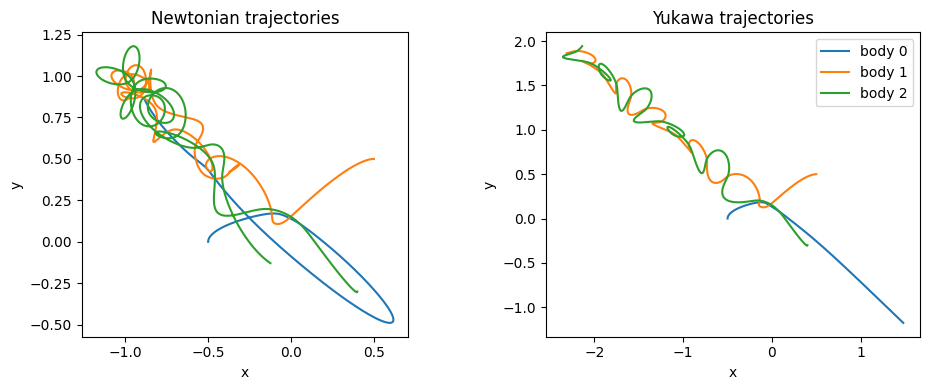

In [7]:
def _pairwise_distances(positions):
    pos = np.asarray(positions, dtype=float)
    if pos.ndim != 2 or pos.shape[1] != 3:
        raise ValueError("positions must be (N, 3)")
    diff = pos[:, None, :] - pos[None, :, :]
    i, j = np.triu_indices(pos.shape[0], k=1)
    distances = np.linalg.norm(diff, axis=-1)
    return distances[i, j]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for rec, ax in zip(records, axes):
    traj = rec["positions"]
    for i in range(traj.shape[1]):
        ax.plot(traj[:, i, 0], traj[:, i, 1], label=f"body {i}")
    ax.set_title(f"{rec['force_type'].capitalize()} trajectories")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
axes[1].legend(loc="best")
fig.tight_layout()

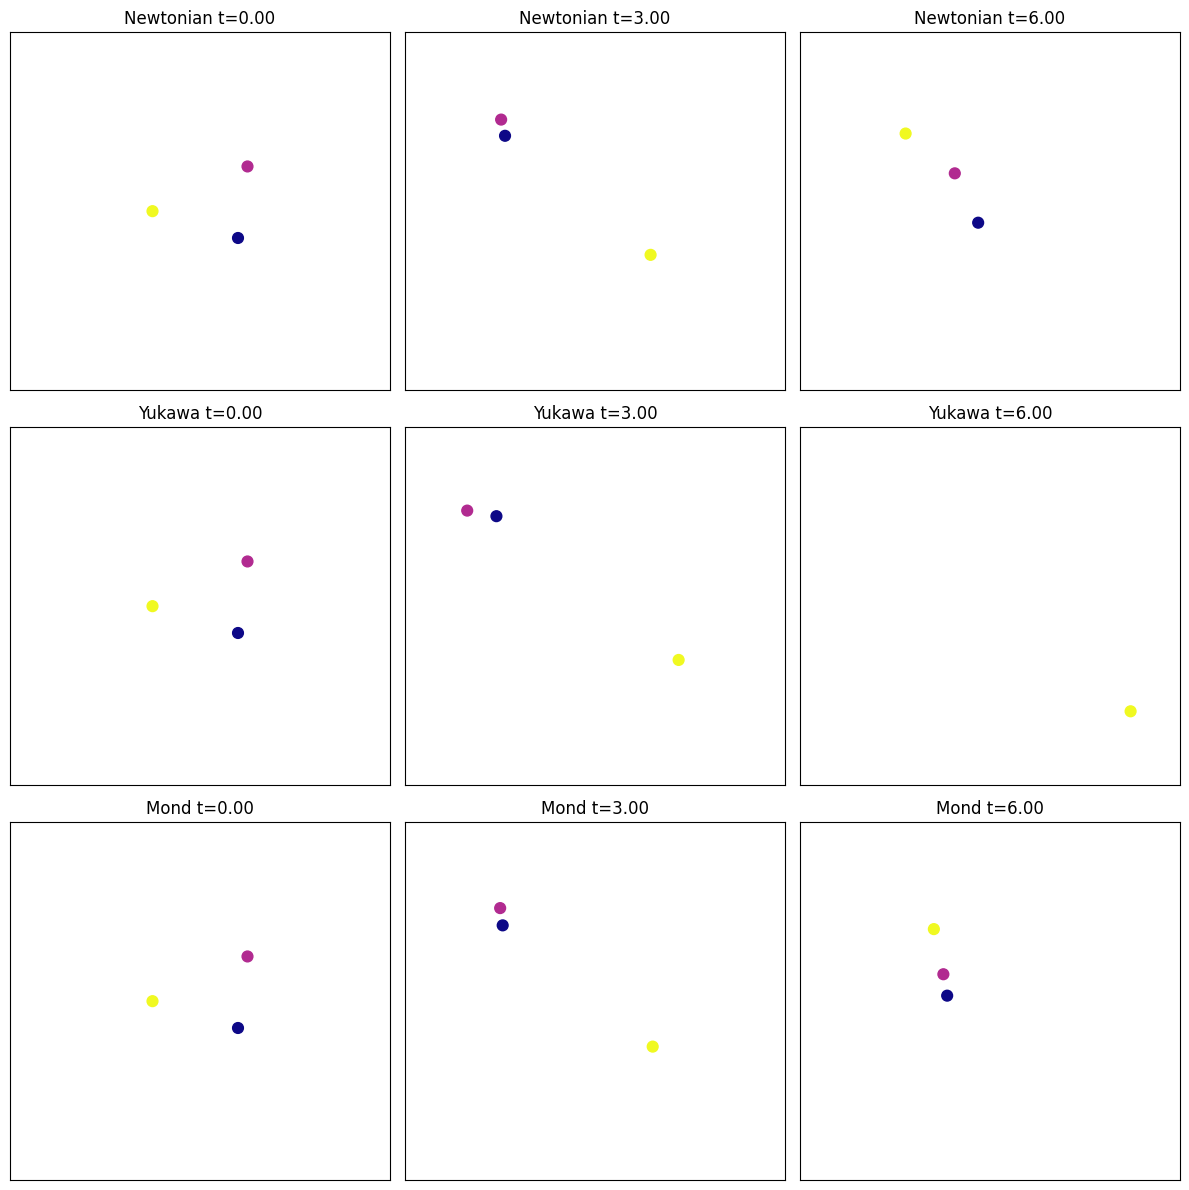

In [10]:
times = [0, len(records[0]["time"]) // 2, -1]
rows = len(records)
fig, axs = plt.subplots(rows, len(times), figsize=(12, 4 * rows), sharex=True, sharey=True)
if rows == 1:
    axs = np.expand_dims(axs, 0)
for row, rec in enumerate(records):
    for col, t_idx in enumerate(times):
        ax = axs[row, col]
        pos = rec["positions"][t_idx]
        ax.scatter(pos[:, 0], pos[:, 1], c=rec["masses"], cmap="plasma", s=60)
        ax.set_title(f"{rec['force_type'].capitalize()} t={rec['time'][t_idx]:.2f}")
        ax.set_xlim(-2, 2)
        ax.set_ylim(-2, 2)
        ax.set_xticks([])
        ax.set_yticks([])
fig.tight_layout()

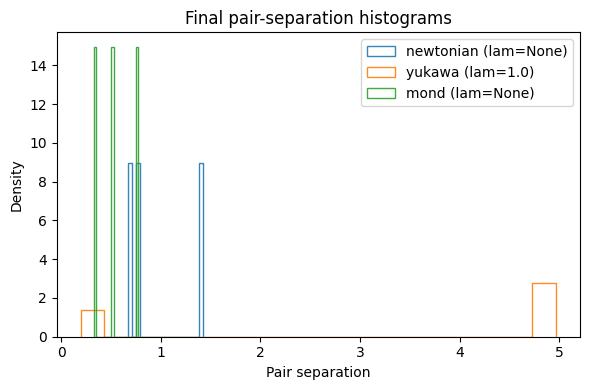

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
for rec in records:
    dists = _pairwise_distances(rec["positions"][-1])
    ax.hist(dists, bins=20, density=True, histtype="step", label=f"{rec['force_type']} (lam={rec['lambda']})", alpha=0.9)
ax.set_xlabel("Pair separation")
ax.set_ylabel("Density")
ax.set_title("Final pair-separation histograms")
ax.legend()
fig.tight_layout()

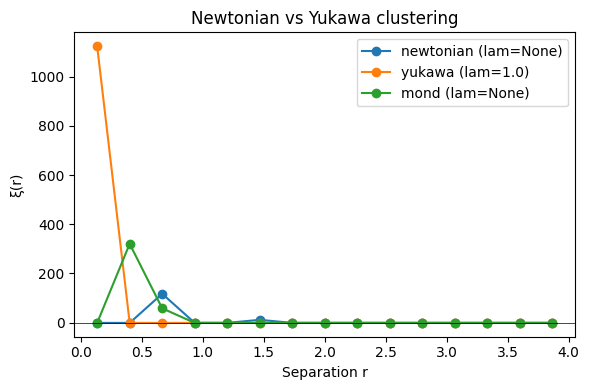

In [12]:
bin_edges = np.linspace(0, 4, 16)
fig, ax = plt.subplots(figsize=(6, 4))
for rec in records:
    centers, xi = two_point_correlation(rec["positions"][-1], bin_edges)
    ax.plot(centers, xi, marker="o", label=f"{rec['force_type']} (lam={rec['lambda']})")
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("Separation r")
ax.set_ylabel("ξ(r)")
ax.set_title("Newtonian vs Yukawa clustering")
ax.legend()
fig.tight_layout()

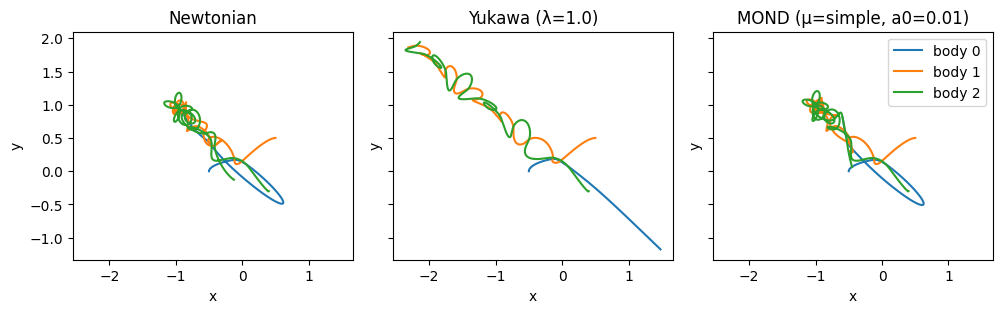

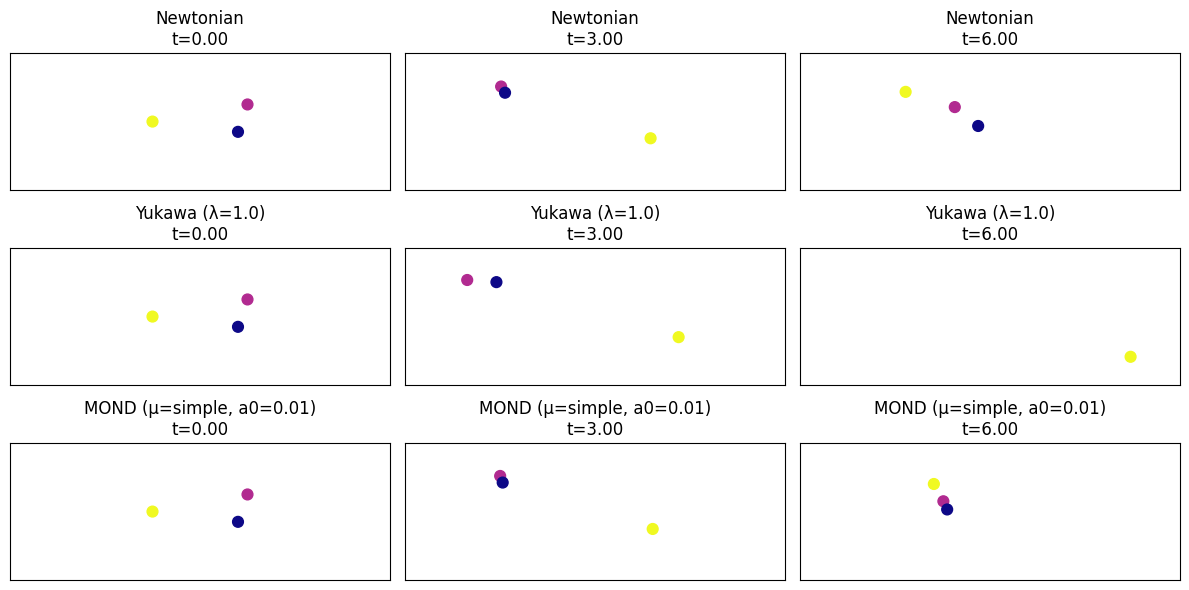

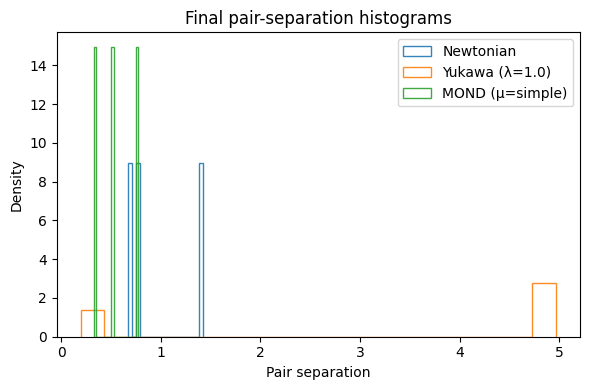

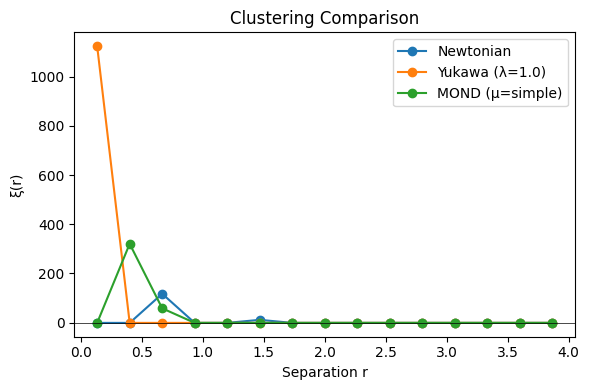

In [13]:
plot_trajectories(records)
times = [0, len(records[0]["time"]) // 2, -1]
plot_snapshots(records, times)
plot_pair_separation_histogram(records)
plot_clustering_overlay(records, np.linspace(0, 4, 16))
plt.show()


In [ ]:
def record_energy_trace(name, positions, velocities, masses, *, dt, steps, force_type="newtonian", lam=None, softening=0.05, mond_params=None):
    pos_hist, vel_hist = run_simulation(
        positions,
        velocities,
        masses,
        dt,
        steps,
        force_type=force_type,
        lam=lam,
        softening=softening,
        mond_params=mond_params,
    )
    energies = np.array([
        compute_total_energy(
            pos_hist[t],
            vel_hist[t],
            masses,
            force_type=force_type,
            lam=lam,
            softening=softening,
            mond_params=mond_params,
        )
        for t in range(steps)
    ])
    return {
        "name": name,
        "force_type": force_type,
        "lambda": lam,
        "dt": dt,
        "steps": steps,
        "softening": softening,
        "time": np.arange(steps) * dt,
        "energies": energies,
        "initial": energies[0],
        "final": energies[-1],
        "mond_params": mond_params,
    }


100%|██████████| 2999/2999 [00:00<00:00, 29910.66it/s]

Two-body Newtonian: ΔE 6.735e-08, rel +8.99e-08, max drift 1.185e-05
Two-body Yukawa: ΔE 9.934e-10, rel +8.49e-09, max drift 4.024e-06


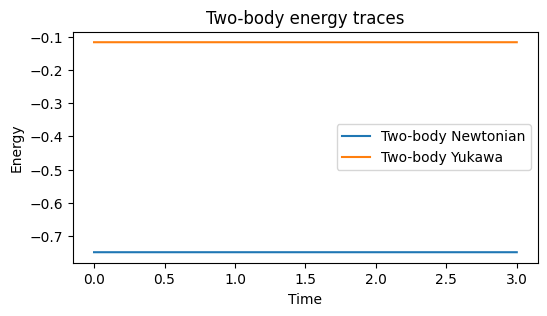

In [ ]:
def make_two_body_configuration():
    masses = np.array([1.0, 1.0])
    positions = np.array([
        [-0.5, 0.0, 0.0],
        [0.5, 0.0, 0.0],
    ], dtype=float)
    velocities = np.array([
        [0.0, 0.5, 0.0],
        [0.0, -0.5, 0.0],
    ], dtype=float)
    return positions, velocities, masses

two_positions, two_velocities, two_masses = make_two_body_configuration()
mond_params = {"a0": 1e-2, "mu": "simple"}
two_configs = [
    record_energy_trace("Two-body Newtonian", two_positions, two_velocities, two_masses, dt=0.001, steps=3000, force_type="newtonian", softening=0.05),
    record_energy_trace("Two-body Yukawa", two_positions, two_velocities, two_masses, dt=0.001, steps=3000, force_type="yukawa", lam=1.0, softening=0.05),
    record_energy_trace("Two-body MOND", two_positions, two_velocities, two_masses, dt=0.001, steps=3000, force_type="mond", softening=0.05, mond_params=mond_params),
]

for rec in two_configs:
    delta = rec["final"] - rec["initial"]
    rel_change = delta / abs(rec["initial"])
    max_dev = np.max(np.abs(rec["energies"] - rec["initial"]))
    print(f"{rec['name']}: ΔE {delta:.3e}, rel {rel_change:+.2e}, max drift {max_dev:.3e}")

fig, ax = plt.subplots(figsize=(6, 3))
for rec in two_configs:
    ax.plot(rec["time"], rec["energies"], label=rec['name'])
ax.set_title("Two-body energy traces")
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.legend()


100%|██████████| 2999/2999 [00:22<00:00, 132.99it/s]


N-body Newtonian: ΔE 4.756e-03, rel +6.04e-05, max drift 4.763e-01
N-body Yukawa: ΔE -8.860e-03, rel -2.44e-04, max drift 4.463e-01


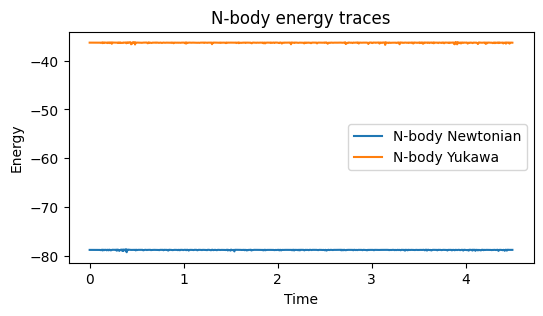

In [ ]:
np.random.seed(123)
N = 12
n_positions = np.random.uniform(-1, 1, size=(N, 3))
n_velocities = np.random.uniform(-0.05, 0.05, size=(N, 3))
n_masses = np.ones(N)
mond_params = {"a0": 1e-2, "mu": "simple"}
nb_configs = [
    record_energy_trace("N-body Newtonian", n_positions, n_velocities, n_masses, dt=0.0015, steps=3000, force_type="newtonian", softening=0.05),
    record_energy_trace("N-body Yukawa", n_positions, n_velocities, n_masses, dt=0.0015, steps=3000, force_type="yukawa", lam=1.0, softening=0.05),
    record_energy_trace("N-body MOND", n_positions, n_velocities, n_masses, dt=0.0015, steps=3000, force_type="mond", softening=0.05, mond_params=mond_params),
]

for rec in nb_configs:
    delta = rec["final"] - rec["initial"]
    rel_change = delta / abs(rec["initial"])
    max_dev = np.max(np.abs(rec["energies"] - rec["initial"]))
    print(f"{rec['name']}: ΔE {delta:.3e}, rel {rel_change:+.2e}, max drift {max_dev:.3e}")

fig, ax = plt.subplots(figsize=(6, 3))
for rec in nb_configs:
    ax.plot(rec["time"], rec["energies"], label=rec['name'])
ax.set_title("N-body energy traces")
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.legend()
